# In this project, we will examine the behavior of the top 10 S&P 500 stocks over recent years, identifying trends, patterns, and key movements.

Data obtained from Kaggle, author: Muhammad Ibrahim Shahrukh

Data coverage period: 04/01/2010 - 02/13/2026


url: https://www.kaggle.com/datasets/ibrahimshahrukh/top-10-s-and-p-500-stocks-2010-2026-analysis

In [2]:
# Connect with google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Import the necessary libraries fro this practice.

[ESP] Importamos librerías necesarias.




In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotnine
import plotly.express as px

### We load our dataset; in this case, we will analyze the performance of the top 10 S&P 500 stocks and then focus specifically on Amazon and Apple over time.

[ESP] Cargamos nuestro dataset, en este caso analizaremos el comportamiento de las acciones top 10 del S&P500 y luego específicamente de Amazon y Apple en el tiempo

In [4]:
# We copy the path where our datasets are located from the files folder in Drive.

sp500_df = pd.read_csv(r"/content/drive/MyDrive/Visualizacion_Avanzada/sp500_top10_stocks_clean.csv")
sp500_df.head()

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
0,2010-01-04,AAPL,6.395005,6.427065,6.363544,6.412384,6.412384,493729600.0
1,2010-01-04,AMZN,6.812500,6.830500,6.657000,6.695000,6.695000,151998000.0
2,2010-01-04,AVGO,1.289115,1.331381,1.268686,1.328563,1.328563,5387000.0
3,2010-01-04,GOOG,15.498976,15.562262,15.431981,15.494032,15.494032,78541293.0
4,2010-01-04,GOOGL,15.571782,15.635366,15.504474,15.566814,15.566814,78169752.0


### We verify the data to ensure there are no null and/or inconsistent values that could affect the visualizations.

[ESP] Verificamos los datos y que no hayan valores nulos y/o inconsistentes que afecten para los gráficos.

In [5]:
sp500_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35765 entries, 0 to 35764
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       35765 non-null  object 
 1   Ticker     35765 non-null  object 
 2   Open       35765 non-null  float64
 3   High       35765 non-null  float64
 4   Low        35765 non-null  float64
 5   Close      35765 non-null  float64
 6   Adj_Close  35765 non-null  float64
 7   Volume     35765 non-null  float64
dtypes: float64(6), object(2)
memory usage: 2.2+ MB


In [6]:
sp500_df.max()

,0
Date,2026-02-13
Ticker,TSLA
Open,789.972167
High,795.064526
Low,779.657506
Close,788.823792
Adj_Close,788.823792
Volume,3692928000.0


### We analyze the maximum and minimum opening and closing prices.

[ESP] Analizamos máximos y mínimos del precio de apertura y cierre.



In [7]:
print(f"Max of column 'Open': {sp500_df['Open'].max()}")
print(f"Min of column 'Open': {sp500_df['Open'].min()}")
print(f"Max of column 'Close': {sp500_df['Close'].max()}")
print(f"Min of column 'Close': {sp500_df['Close'].min()}")

Max of column 'Open': 789.9721665216805
Min of column 'Open': 0.1998699002080865
Max of column 'Close': 788.8237915039062
Min of column 'Close': 0.2035371959209442


In [8]:
sp500_df.describe(include='all')

,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume
count,35765,35765,35765.000000,35765.000000,35765.000000,35765.000000,35765.000000,3.576500e+04
unique,4054,9,NaN,NaN,NaN,NaN,NaN,NaN
top,2026-02-13,AAPL,NaN,NaN,NaN,NaN,NaN,NaN
freq,9,4054,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,92.590518,93.765511,91.365589,92.595168,92.595168,1.202461e+08
std,NaN,NaN,115.952363,117.408637,114.358373,115.898831,115.898831,1.919208e+08
min,NaN,NaN,0.199870,0.207434,0.198265,0.203537,0.203537,1.584340e+05
25%,NaN,NaN,15.297000,15.460000,15.125859,15.300667,15.300667,2.544150e+07
50%,NaN,NaN,41.214919,41.580309,40.863378,41.232372,41.232372,4.974370e+07
75%,NaN,NaN,140.091398,141.880992,138.391384,140.202179,140.202179,1.129584e+08


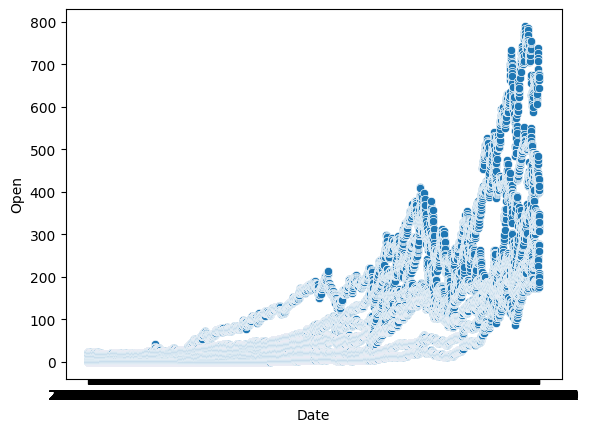

In [9]:
sns.scatterplot(data=sp500_df, x="Date" , y="Open")
plt.show()

#### In this first visualization, we can see that due to the high volume of data, it is not possible to observe a clear distribution. Therefore, we will group the data by stock and by year to obtain a clearer visualization and better identify the trend.

[ESP] En esta primera visualización vemos que por el alto volumen de datos no es posible observar una distribución clara, por lo que agruparemos los datos por acción y por año para tener una visualización más clara y observar la tendencia.

In [10]:
sp500_df.rename(columns={'Ticker': 'Company'}, inplace=True)

In [11]:
# Make sure Date is actually in datetime format.
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'])

# Extract Year from datetime
sp500_df['Year'] = sp500_df['Date'].dt.year

sp500_df.head()

,Date,Company,Open,High,Low,Close,Adj_Close,Volume,Year
0,2010-01-04,AAPL,6.395005,6.427065,6.363544,6.412384,6.412384,493729600.0,2010
1,2010-01-04,AMZN,6.812500,6.830500,6.657000,6.695000,6.695000,151998000.0,2010
2,2010-01-04,AVGO,1.289115,1.331381,1.268686,1.328563,1.328563,5387000.0,2010
3,2010-01-04,GOOG,15.498976,15.562262,15.431981,15.494032,15.494032,78541293.0,2010
4,2010-01-04,GOOGL,15.571782,15.635366,15.504474,15.566814,15.566814,78169752.0,2010


,Year,Company,Close
0,2010,AAPL,9.752063
1,2010,AMZN,9.238000
2,2010,AVGO,2.039814
3,2010,GOOG,15.494525
4,2010,GOOGL,15.567313


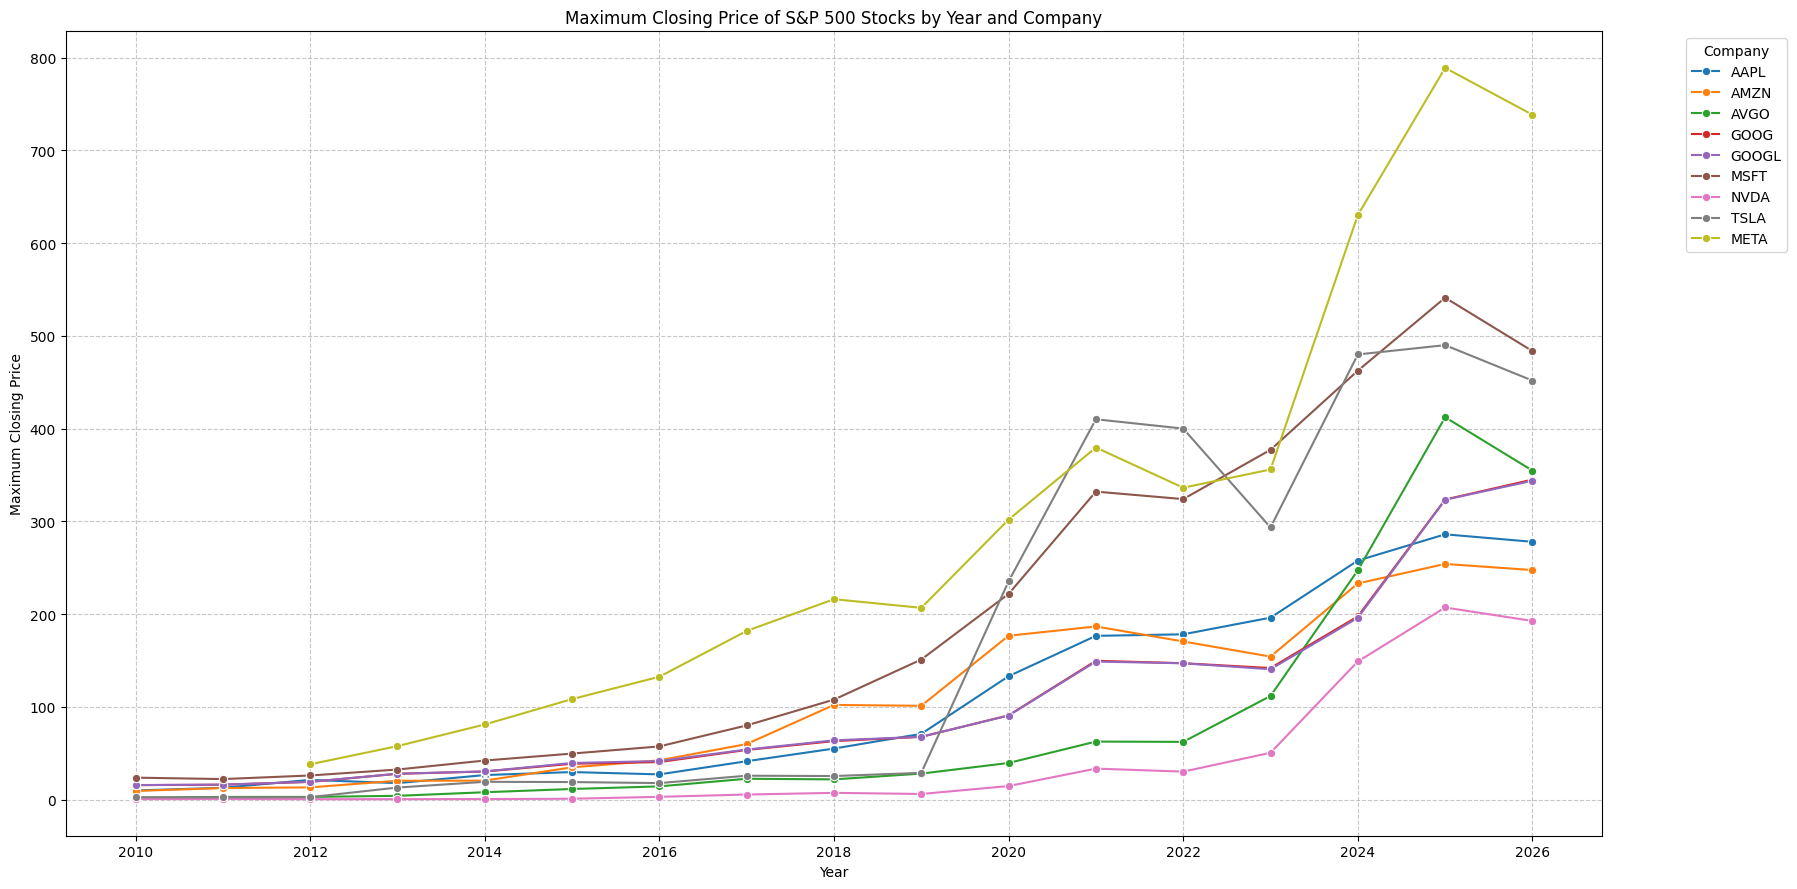

In [12]:
# Group the data in sp500_df by 'Company' and 'Year' and calculate the maximum closing price.

grouped_sp500_close = sp500_df.groupby(['Year', 'Company'])['Close'].max().reset_index()

display(grouped_sp500_close.head())

plt.figure(figsize=(18, 9))
sns.lineplot(data=grouped_sp500_close, x='Year', y='Close', hue='Company', marker='o')
plt.title('Maximum Closing Price of S&P 500 Stocks by Year and Company')
plt.xlabel('Year')
plt.ylabel('Maximum Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### We can see that from 2010 to 2014, S&P 500 stocks did not experience significant changes in the market (with the exception of Meta). Therefore, we will proceed with a more detailed analysis by quarter — Q1, Q2, Q3, and Q4 — from 2014 to the present.

#### At first glance, we can observe that some stocks show a significant gap in closing price compared to others, we will analyze this further in next steps.

[ESP] Podemos apreciar que desde los años 2010 hasta el 2014 (a excepción de Meta) las acciones del S&P500 no tuvieron un cambio significativo en la bolsa, por lo que procederemos a analizar más a detalle por trimestre Q1, Q2, Q3 y Q4 entre los años 2014-actual:

En este primer vistazo podemos apreciar que hay unas acciones con una brecha significativa con respecto al precio de cierre por stock.

In [13]:
# We apply a filter for the data after 2014
sp500_df_filtered = sp500_df[sp500_df['Year'] >= 2014].copy()

In [14]:
# Extract the quarter.
sp500_df_filtered['Quarter'] = sp500_df_filtered['Date'].dt.quarter

grouped_by_quarter = sp500_df_filtered.groupby(['Year','Company', 'Quarter'])['Close'].max().reset_index()

grouped_by_quarter['Quarter'] = grouped_by_quarter['Quarter'].map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})

display(grouped_by_quarter.head())

,Year,Company,Quarter,Close
0,2014,AAPL,Q1,17.271748
1,2014,AAPL,Q2,20.681908
2,2014,AAPL,Q3,22.780561
3,2014,AAPL,Q4,26.356649
4,2014,AMZN,Q1,20.352501


In [15]:
grouped_by_quarter['Year_Quarter'] = grouped_by_quarter['Year'].astype(str) + '-' + grouped_by_quarter['Quarter']
display(grouped_by_quarter.head())

,Year,Company,Quarter,Close,Year_Quarter
0,2014,AAPL,Q1,17.271748,2014-Q1
1,2014,AAPL,Q2,20.681908,2014-Q2
2,2014,AAPL,Q3,22.780561,2014-Q3
3,2014,AAPL,Q4,26.356649,2014-Q4
4,2014,AMZN,Q1,20.352501,2014-Q1


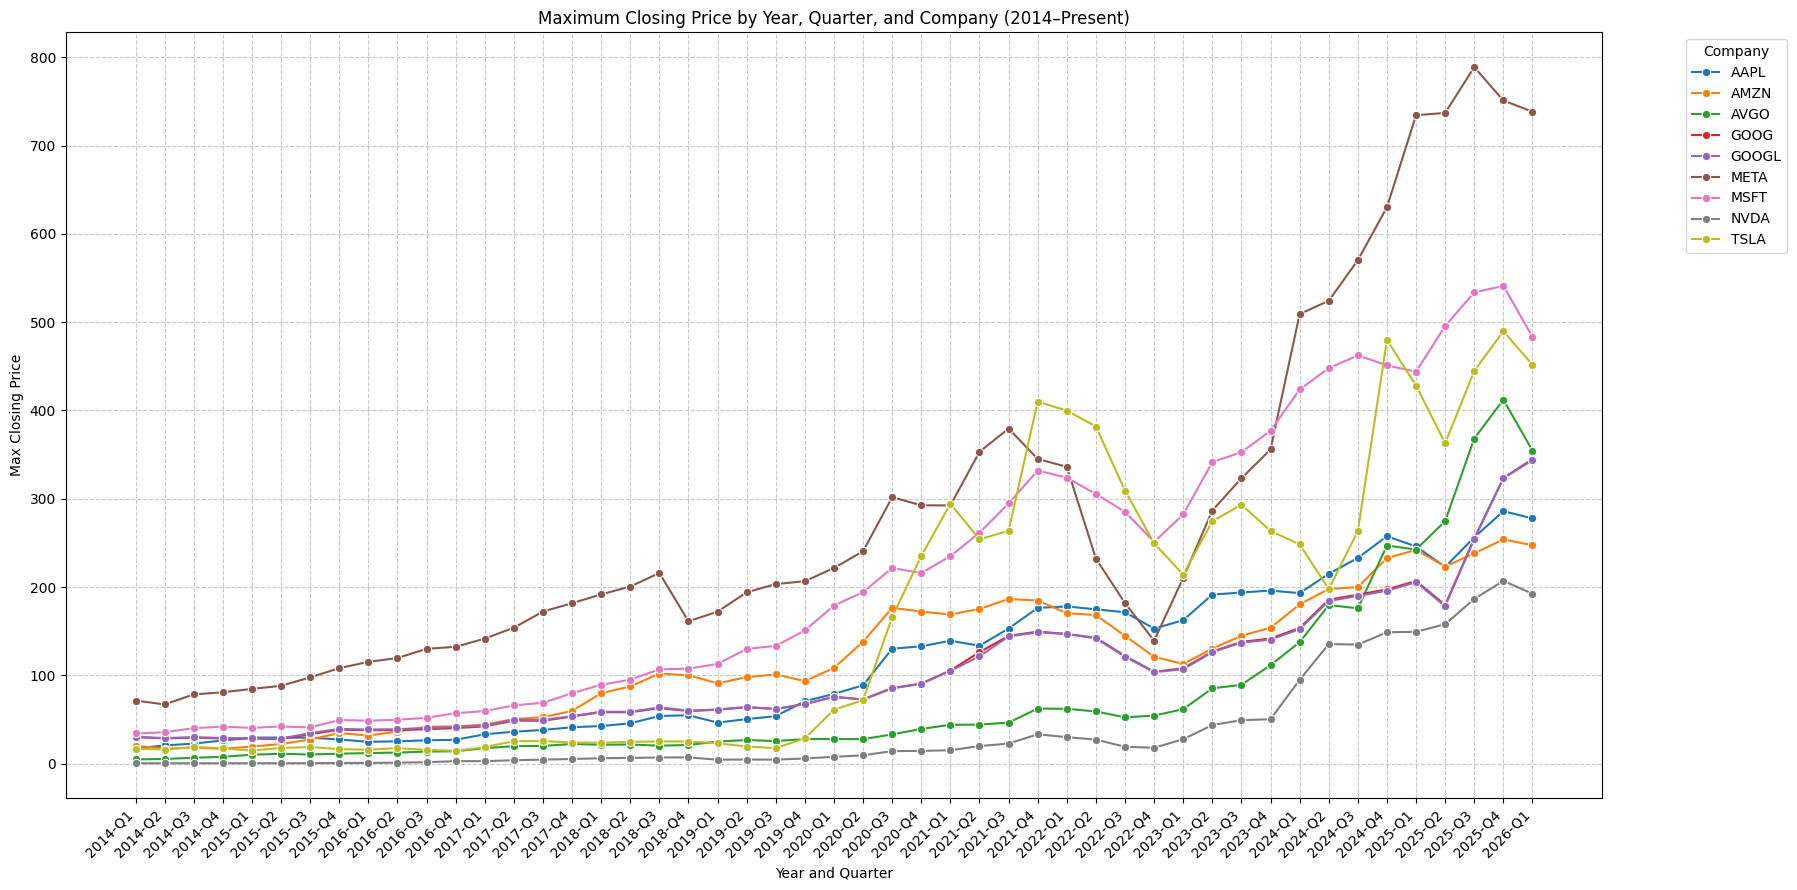

In [16]:
plt.figure(figsize=(18, 9))
sns.lineplot(data=grouped_by_quarter, x='Year_Quarter', y='Close', hue='Company', marker='o', errorbar=None, palette='tab10')
plt.title('Maximum Closing Price by Year, Quarter, and Company (2014–Present)')
plt.xlabel('Year and Quarter')
plt.ylabel('Max Closing Price')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### From the quarterly visualization, we can clearly observe that during the COVID-19 pandemic, the top 10 S&P 500 stocks increased in value due to the growing use of technology in both academic settings and remote work within companies. However, by the end of 2021 and into Q1 2022, stock prices began to follow a downward trend, correcting after the global lockdown period as in-person activities gradually resumed and new technologies emerged.


[ESP] Podemos observar puntualmente con la visualización por trimestres que durante la pandemia del Covid-19 las acciones del top 10 del SP500 subieron debido por el aumento en el uso de tecnologías tanto el ámbito académico como en el trabajo remoto dentro de las empresas, pero al finalizar el 2021-2022(Q1) las acciones tomaron una tendencia bajista para corregir un poco el precio luego de pasar el confinamiento global y la vuelta poco a poco a la presencialidad y surgimiento de nuevas tecnologías.

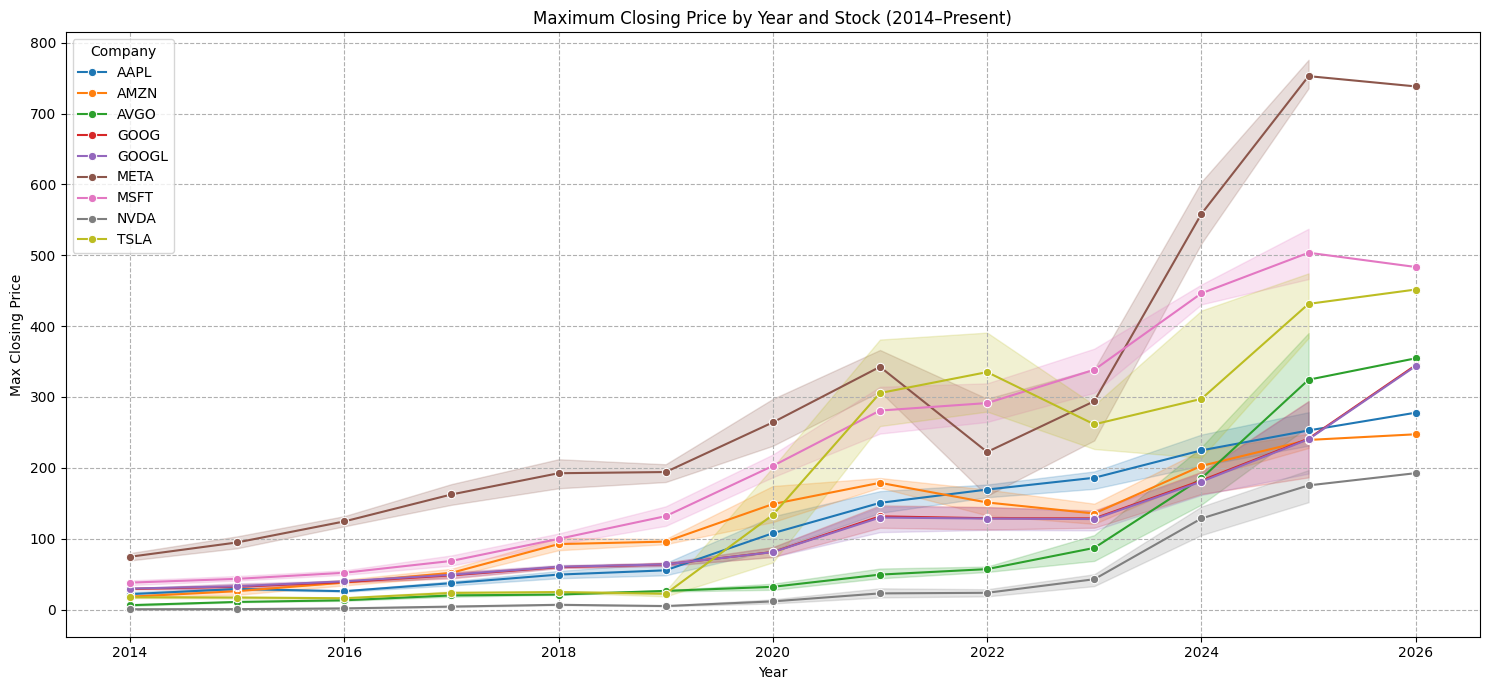

In [17]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=grouped_by_quarter, x='Year', y='Close', hue='Company', palette='tab10', marker='o')
plt.title('Maximum Closing Price by Year and Stock (2014–Present)')
plt.xlabel('Year')
plt.ylabel('Max Closing Price')
plt.grid(True, linestyle='--')
plt.legend(title='Company')
plt.tight_layout()
plt.show()

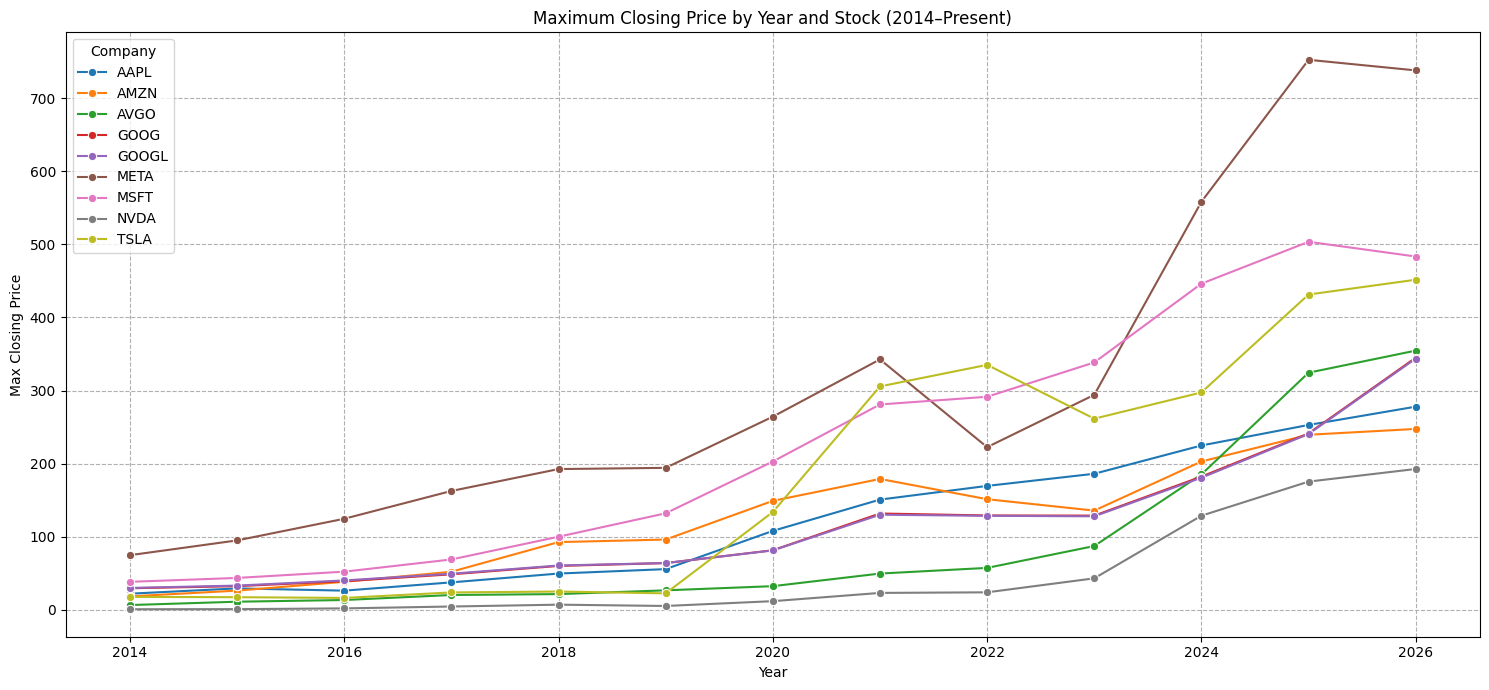

In [18]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=grouped_by_quarter, x='Year', y='Close', hue='Company', palette='tab10', marker='o', errorbar=None)
plt.title('Maximum Closing Price by Year and Stock (2014–Present)')
plt.xlabel('Year')
plt.ylabel('Max Closing Price')
plt.grid(True, linestyle='--')
plt.legend(title='Company')
plt.tight_layout()
plt.show()

#### From the chart, we can observe that, based on these reference data, the stocks could be grouped into two categories:

#### On one hand, we have Meta, MSFT, and Tesla as the stocks with considerably higher prices than the rest. With this in mind, we will adjust the initial premise and later compare the behavior of Tesla and MSFT, since they are high-value stocks with similar performance.

[ESP] Podemos observar en la gráfica que podriamos agrupar según estos datos de referencia el comportamiento de las acciones en dos grupos:

Por un lado tenemos a Meta, MSFT y Tesla en las acciones con un precio considerablemente mayor que el resto, teniendo esto en cuenta cambiaremos la premicia inicial y compararemos luego el comportamiento de Tesla y MSFT debido a que son acciones de valor con un comportamiento similar

In [19]:
max_close_by_company_year = sp500_df.groupby(['Company', 'Year'])['Close'].max().reset_index()

display(max_close_by_company_year.head())

,Company,Year,Close
0,AAPL,2010,9.752063
1,AAPL,2011,12.651579
2,AAPL,2012,21.127348
3,AAPL,2013,17.666227
4,AAPL,2014,26.356649


In [20]:
fig = px.treemap(max_close_by_company_year, path=['Company', 'Year'], values='Close',
                 title='Max Closing Price, grouped by Company and Year',
                 color='Close', color_continuous_scale='Viridis')
fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

#### We will examine the data from the last 10 years to identify the most profitable stocks and interactively observe how they have evolved over time.

[ESP] Veremos los datos de los últimos 10 años para ver cuales son las acciones más rentables y poder ver de una forma interactiva como han evolucionado a lo largo del tiempo





In [21]:
# Apply the filter for last 10 years

sp500_df_10years = sp500_df[sp500_df['Year'] >= 2016].copy()

In [22]:
max_close_by_company_year_10anos = sp500_df_10years.groupby(['Company', 'Year'])['Close'].max().reset_index()

fig = px.treemap(max_close_by_company_year_10anos, path=['Company', 'Year'], values='Close',
                 title='Maximum Closing Price by Company (2016–Present)',
                 color='Close', color_continuous_scale='Viridis')

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

In [23]:
company_avg_close = sp500_df_10years.groupby(['Company','Year'])['Close'].mean().reset_index()

display(company_avg_close.head())

,Company,Year,Close
0,AAPL,2016,23.855403
1,AAPL,2017,34.981397
2,AAPL,2018,44.597007
3,AAPL,2019,49.902126
4,AAPL,2020,92.434113


In [24]:
fig = px.treemap(company_avg_close, path=['Company','Year'], values='Close',
                 title='Average Closing Price by Company',
                 color='Close', color_continuous_scale='RdYlGn')

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

In [25]:
# Filter data for Tesla y MSFT stocks from 2014

tesla_msft_df = sp500_df_filtered[sp500_df_filtered['Company'].isin(['TSLA', 'MSFT'])].copy()

display(tesla_msft_df.head())

,Date,Company,Open,High,Low,Close,Adj_Close,Volume,Year,Quarter
8339,2014-01-02,MSFT,30.988772,31.030259,30.781351,30.831133,30.831133,30632200.0,2014,1
8341,2014-01-02,TSLA,9.986667,10.165333,9.770000,10.006667,10.006667,92826000.0,2014,1
8348,2014-01-03,MSFT,30.864322,30.880916,30.366509,30.623713,30.623713,31134800.0,2014,1
8350,2014-01-03,TSLA,10.000000,10.146000,9.906667,9.970667,9.970667,70425000.0,2014,1
8357,2014-01-06,MSFT,30.573936,30.607125,29.959970,29.976564,29.976564,43603700.0,2014,1


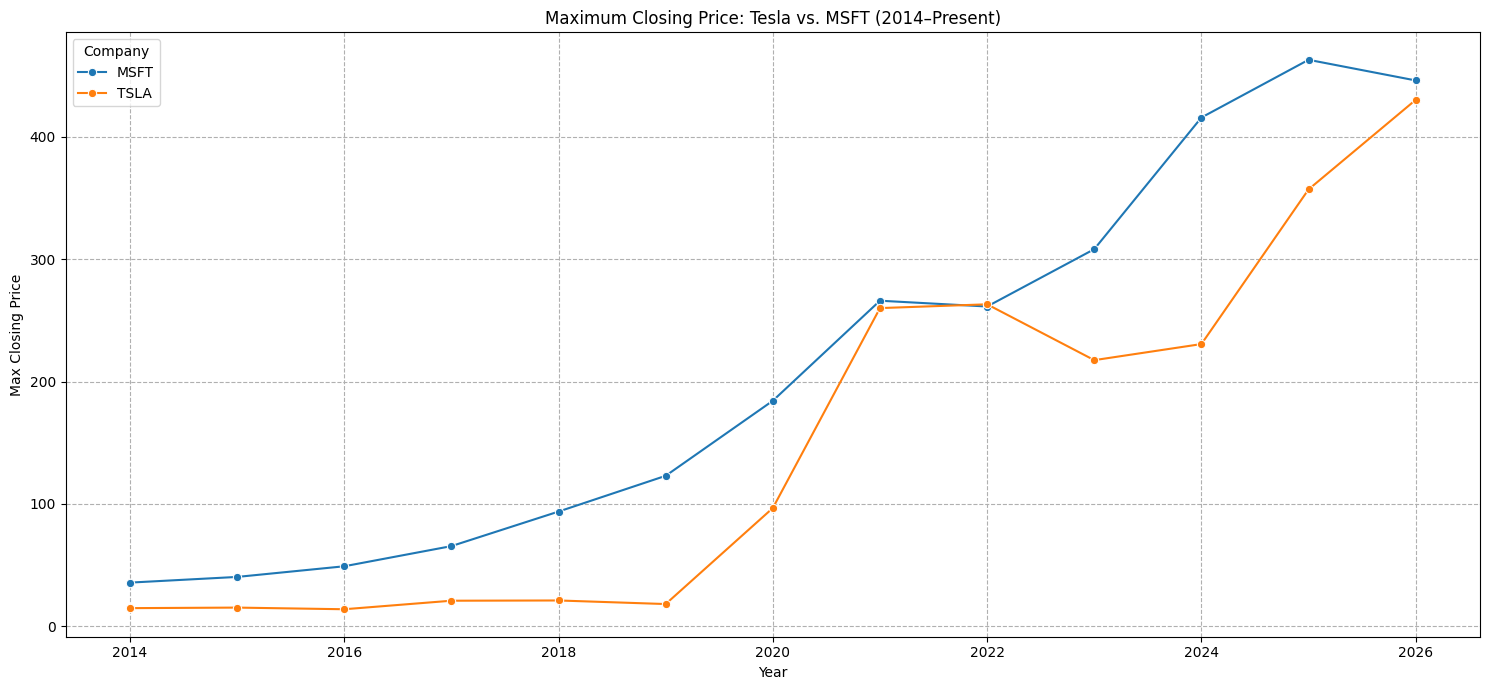

In [26]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=tesla_msft_df, x='Year', y='Close', hue='Company', marker='o', errorbar=None)
plt.title('Maximum Closing Price: Tesla vs. MSFT (2014–Present)')
plt.xlabel('Year')
plt.ylabel('Max Closing Price')
plt.grid(True, linestyle='--')
plt.legend(title='Company')
plt.tight_layout()
plt.show()

#### At first glance, we can see that MSFT has maintained an upward trend since 2014, with higher closing prices than Tesla. There is a clear turning point in Tesla’s stock between 2021 and 2022, which was presumably driven by several factors, including Elon Musk’s acquisition of Twitter, the production disruptions caused by COVID-19 during the first part of the year, and a Tesla stock split. Meanwhile, MSFT maintained steady growth throughout the observed period.

[ESP] Podemos apreciar a simple vista como MSFT siempre ha tenido una tendencia alcista desde el 2014 y con precios de cierre más altos que Tesla, hay un punto de inflexión en las acciones de Tesla en el 2021-2022, esto se debe a varios factores (presuntamente) por la adquisición de Twitter por parte de Elon Musk, las interrupciones que generó el Covid-19 en la producción en la primera parte del año y un split en las acciones de TESLA. MSFT por su parte se mantuvo constante con su crecimiento durante el periodo observado.

In [27]:
# Finally we extract the last year to see behavior in short term.
sp500_2025_26 = sp500_df[sp500_df['Year'] >= 2025]


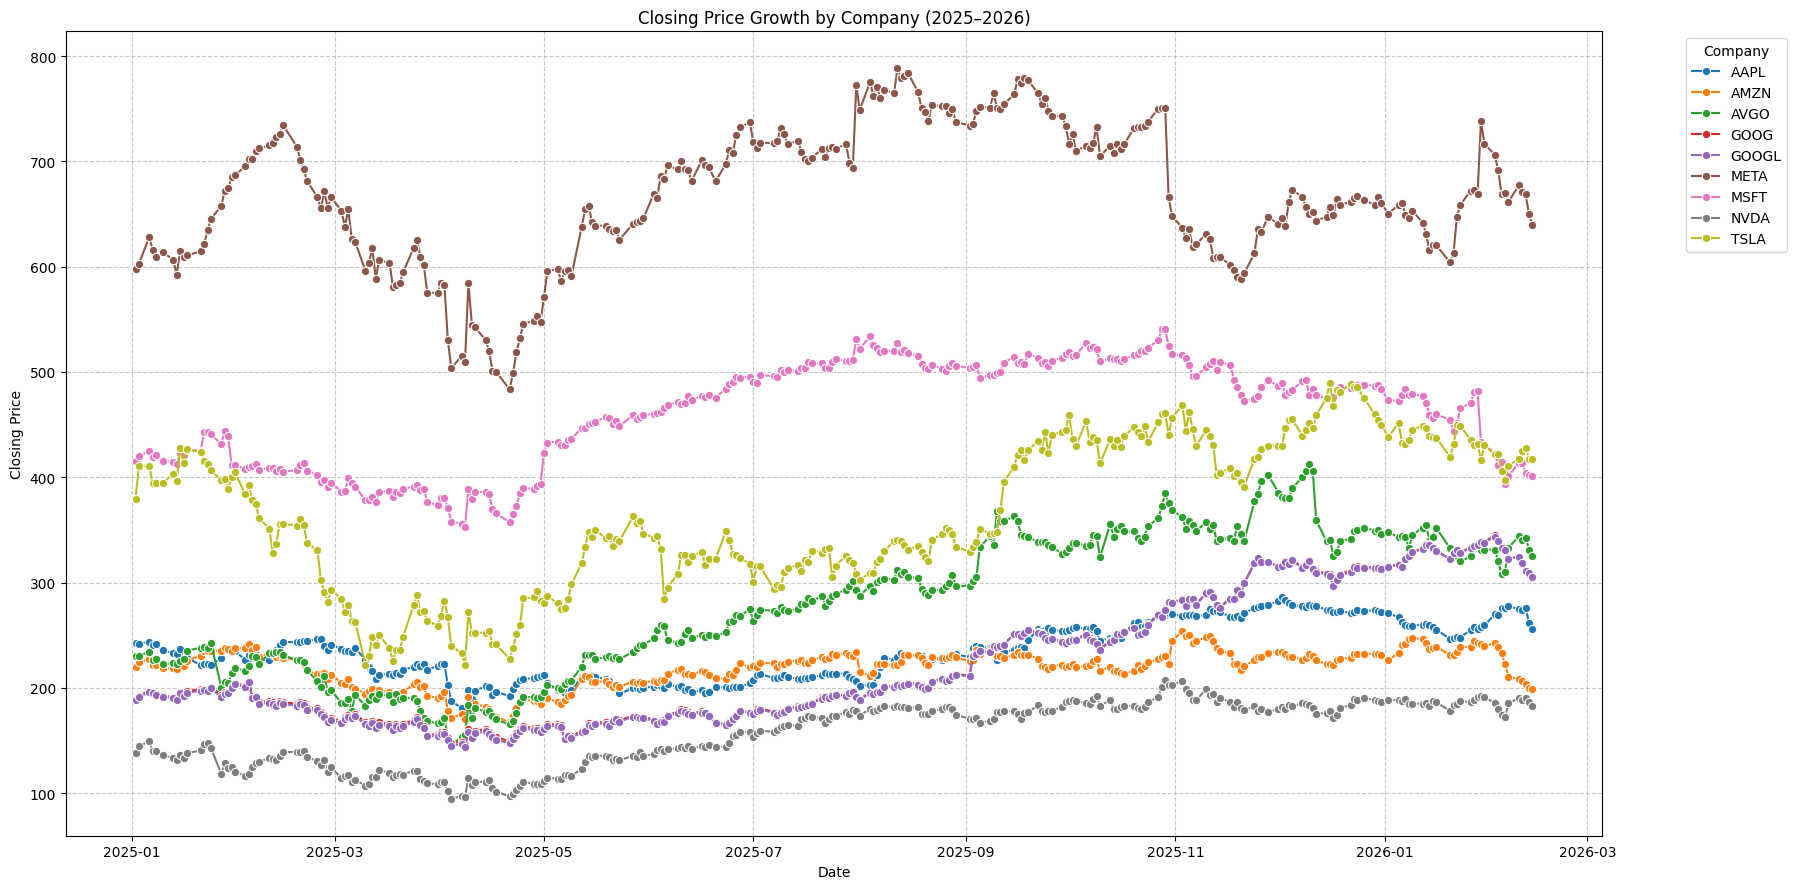

In [28]:
plt.figure(figsize=(18, 9))
sns.lineplot(data=sp500_2025_26, x='Date', y='Close', hue='Company', marker='o', errorbar=None)
plt.title('Closing Price Growth by Company (2025–2026)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### It is not entirely clear from the following chart which stock has shown the greatest growth from the beginning of 2025 to the present. Therefore, we will represent it in a bar chart with the corresponding percentage, allowing us to obtain a more objective and short-term view of which stock has experienced the highest growth over the last year and whether it aligns with the trend shown in its chart.

[ESP] No nos queda muy claro con la siguiente gráfica cual acción presenta el mayor crecimiento desde el cierre de principios de 2025 a la fecha, por lo que lo representaremos en un gráfico de barras con su respectivo porcentaje, de esta manera tendremos un valor más objetivo y cercano a la realidad del corto plazo para ver cual acción ha presentado mayor crecimiento en el último año y ver si es acorde a la tendencia de su gráfica.

In [29]:
sp500_df['Date'] = pd.to_datetime(sp500_df['Date'])

# Get the opening price for the 01/01/2025
open_2025 = sp500_df[(sp500_df['Date'] == '2025-01-02')][['Company', 'Open']].rename(columns={'Open': 'Open_2025_01_02'})

# Get the closing price for the 01/01/2026
close_2026 = sp500_df[(sp500_df['Date'] == '2026-01-02')][['Company', 'Close']].rename(columns={'Close': 'Close_2026_01_02'})

# Join by 'Company'
merged_prices = pd.merge(open_2025, close_2026, on='Company', how='inner')

# Extract the %
merged_prices['Growth % 2025'] = round(((merged_prices['Close_2026_01_02'] - merged_prices['Open_2025_01_02']) / merged_prices['Open_2025_01_02']) * 100,2)

display(merged_prices[['Company', 'Growth % 2025']])

,Company,Growth % 2025
0,AAPL,9.36
1,AMZN,2.01
2,AVGO,48.53
3,GOOG,65.31
4,GOOGL,65.95
5,META,10.64
6,MSFT,11.96
7,NVDA,38.90
8,TSLA,12.30


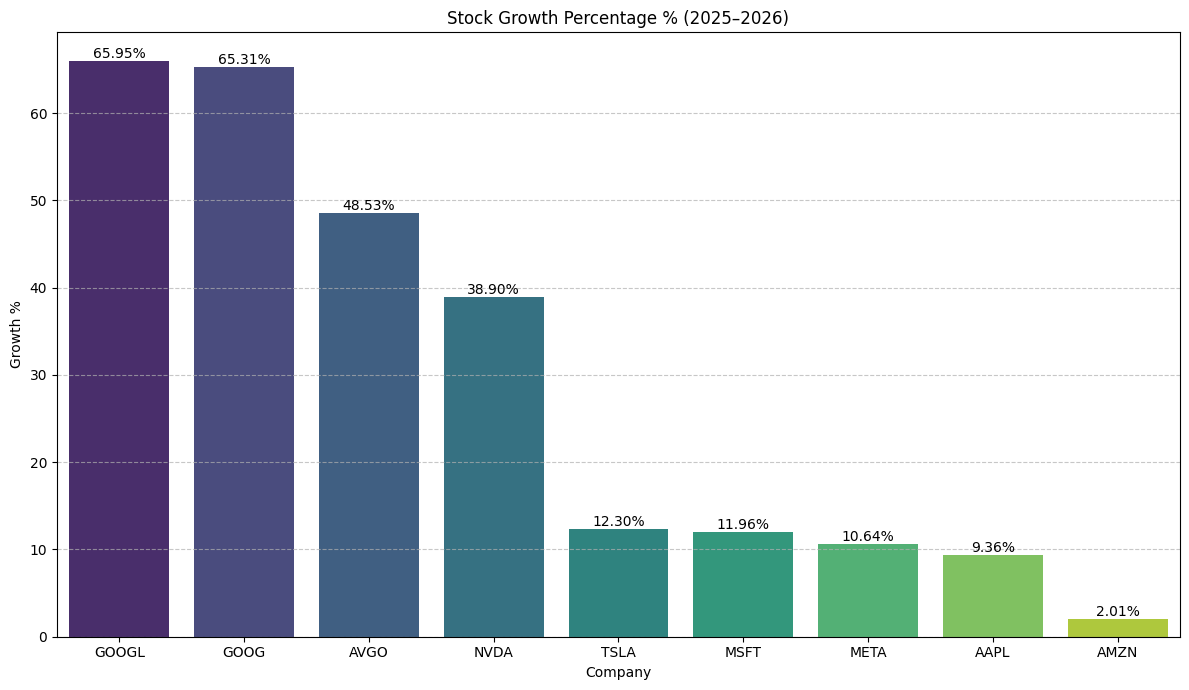

In [30]:
plt.figure(figsize=(12, 7))
sns.barplot(y='Growth % 2025', x='Company', hue='Company', data=merged_prices.sort_values(by='Growth % 2025', ascending=False), palette='viridis', legend=False)
plt.title('Stock Growth Percentage % (2025–2026)')
plt.xlabel('Company')
plt.ylabel('Growth %')
plt.grid(axis='y', linestyle='--', alpha=0.7)


for index, row in merged_prices.sort_values(by='Growth % 2025', ascending=False).iterrows():
    plt.text(row['Company'], row['Growth % 2025'], f'{row['Growth % 2025']:.2f}%', color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

#### As a final conclusion, we can observe that the stocks showing the highest growth over the last year were Google, AVGO, and NVIDIA, which could make them attractive investment options. Likewise, it is worth noting that Meta stock has shown a consistent upward trend, making it appear to be a relatively “safe” investment option.

#### The long-term analysis shows that not all top 10 S&P 500 stocks behave in the same way, as some present much stronger and more sustained growth patterns than others. This highlights the importance of comparing both short-term fluctuations and long-term trends before making investment decisions.

#### Stocks such as Google, AVGO, and NVIDIA showed stronger short-term growth, which may indicate momentum and investor confidence during the most recent period analyzed. On the other hand, companies such as Microsoft and Meta appeared to display more stable long-term upward trends, which could be more attractive for investors seeking consistency rather than short-term acceleration.

---



[ESP] Como conclusión final, podemos observar que las acciones que mostraron el mayor crecimiento durante el último año fueron Google, AVGO y NVIDIA, lo que podría convertirlas en opciones de inversión atractivas. Asimismo, cabe destacar que las acciones de Meta han mostrado una tendencia alcista constante, lo que las hace parecer una opción de inversión relativamente “segura”.

El análisis a largo plazo muestra que no todas las acciones del top 10 del S&P 500 se comportan de la misma manera, ya que algunas presentan patrones de crecimiento mucho más fuertes y sostenidos que otras. Esto resalta la importancia de comparar tanto las fluctuaciones a corto plazo como las tendencias a largo plazo antes de tomar decisiones de inversión.

Acciones como Google, AVGO y NVIDIA mostraron un crecimiento más fuerte a corto plazo, lo que puede indicar impulso y confianza por parte de los inversionistas durante el período más reciente analizado. Por otro lado, compañías como Microsoft y Meta parecen mostrar tendencias alcistas más estables a largo plazo, lo que podría resultar más atractivo para inversionistas que buscan consistencia en lugar de una aceleración de corto plazo.